# Assessing Learnability

## Notebook Outline

1. Load and merge salary, player statistics, and team data
2. Check basic signal, sample size, and feature-target alignment
3. Compare Dummy, Linear Regression, and Random Forest models
4. Review domain and technical limitations
5. Summarize learnability and next steps

## 1. Data Loading & Integration

Load all six raw CSV files, merge player salary with player production, and attach team context for the modeling dataset.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
repo = Path.cwd().parent
data_dir = repo / "data" / "raw"

adv = pd.read_csv(data_dir / "2025_advanced.csv")
per = pd.read_csv(data_dir / "2025_per_game.csv")
tot = pd.read_csv(data_dir / "2025_totals.csv")
sal = pd.read_csv(data_dir / "salary_2025.csv")
teamadv = pd.read_csv(data_dir / "2025_advanced-team.csv")
stand = pd.read_csv(data_dir / "2025_wnba_standings.csv")

print("advanced:", adv.shape)
print("per game:", per.shape)
print("totals:", tot.shape)
print("salary:", sal.shape)
print("team advanced:", teamadv.shape)
print("standings:", stand.shape)

advanced: (182, 24)
per game: (182, 27)
totals: (182, 26)
salary: (227, 27)
team advanced: (13, 27)
standings: (13, 5)


### Basic Cleaning

Before merging the datasets, standardize column names and clean simple text values.

For example, column names like `2025 Salary` and `FG%` are converted to simpler formats such as `salary` and `fgpct`.
The salary column is also converted to numeric format because it will be used as the regression target.

In [4]:
# Standardize column names into a code-friendly format
def clean_col(name):
    text = str(name).strip().lower()
    text = text.replace("2025 salary", "salary")
    text = text.replace("2025 signing", "signing")
    text = text.replace("%", "pct")

    # Replace spaces and symbols with underscores
    text = re.sub(r"[^0-9a-z]+", "_", text)
    text = text.strip("_")
    return text

# Apply basic cleaning to one dataframe
def clean_df(df):
    # Apply the same column-name format to each dataset
    df.columns = [clean_col(col) for col in df.columns]

    # Clean text columns by removing extra spaces and standardizing missing values
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"": np.nan, "—": np.nan, "nan": np.nan})

    return df

adv = clean_df(adv)
per = clean_df(per)
tot = clean_df(tot)
sal = clean_df(sal)
teamadv = clean_df(teamadv)
stand = clean_df(stand)

# Salary is the regression target, so it must be numeric
sal["salary"] = pd.to_numeric(sal["salary"], errors="coerce")

### Final Data Merge and Name Matching

In this step, create the final modeling dataframe by combining player production, salary, and team-level data.

The merge process has three main parts:

1. Align team names  
   The team-level files use full team names, while the player-level files use team abbreviations. Mapping full team names to abbreviations so the team data can be merged with player data.

2. Combine player production data  
   Merge per-game, advanced, and total-count player statistics into one player-level production dataframe for each season.

3. Match player names before the final merge  
   Before merging salary data with production data, check which players appear only in the salary file or only in the production tables. Some differences come from encoding issues or slightly different name formats, so manually correct clear mismatches before creating the final dataset.

The final dataframe is created with an inner merge, meaning it keeps only players who have both salary data and on-court production data. Players appearing only in the salary file are excluded because they do not have usable 2025 production statistics for this modeling task.

In [5]:
# Map full team names from team-level files to the abbreviations used in player-level files
teammap = {
    "Atlanta Dream": "ATL",
    "Chicago Sky": "CHI",
    "Connecticut Sun": "CON",
    "Dallas Wings": "DAL",
    "Golden State Valkyries": "GSV",
    "Indiana Fever": "IND",
    "Las Vegas Aces": "LVA",
    "Los Angeles Sparks": "LAS",
    "Minnesota Lynx": "MIN",
    "New York Liberty": "NYL",
    "Phoenix Mercury": "PHO",
    "Seattle Storm": "SEA",
    "Washington Mystics": "WAS",
}

def team_clean(val):
    if pd.isna(val):
        return np.nan
    
    # Basketball Reference marks some teams with "*"; remove it before mapping
    return str(val).replace("*", "").strip()

# Standardize team names so team-level data can merge with player-level data
teamadv["team_name"] = teamadv["team"].map(team_clean)  # ex) Atlanta Dream
teamadv["team"] = teamadv["team_name"].map(teammap)     # ex) ATL
stand["team_name"] = stand["team_name"].map(team_clean)
stand["team"] = stand["team_name"].map(teammap)

# Combine team advanced stats with standings data
teamdf = teamadv.merge(stand, on=["team", "team_name"], how="left", suffixes=("_adv", "_stand"))

# Merge per_game and advanced player stats into one production dataframe
playerdf = per.merge(adv, on=["player", "team", "pos", "g", "mp"], how="outer", suffixes=("_per", "_adv"))

# Add total count stats to the same player production dataframe.
playerdf = playerdf.merge(tot, on=["player", "team", "pos", "g", "mp", "gs"], how="outer", suffixes=("", "_tot"))

# Check player name mismatches before creating final_df
salary_only = sal[~sal["player"].isin(playerdf["player"])]
stats_only = playerdf[~playerdf["player"].isin(sal["player"])]

print("Before name fixes")
print("Salary only players:")
print(sorted(salary_only["player"].dropna().unique()))

print("\nStats only players:")
print(sorted(stats_only["player"].dropna().unique()))

Before name fixes
Salary only players:
['Anastasiia Olairi Kosu', 'Georgia Amoore', 'Janelle Salaun', 'Katie Lou Samuelson', 'Leila Lacan', 'Luisa Geiselsoder', 'Mamignan Touré', 'Marième Badiane', 'Sika Kone', 'Te-Hina Paopao']

Stats only players:
['Anastasiia Kosu', 'Janelle SalaÃ¼n', 'LeÃ¯la Lacan', 'Luisa GeiselsÃ¶der', 'Mamignan TourÃ©', 'MariÃ¨me Badiane', 'Sika KonÃ©', 'Te-Hina PaoPao']


In [6]:
# Manually fix clear name encoding/spelling mismatches
name_fix = {
    "Anastasiia Kosu": "Anastasiia Olairi Kosu",
    "Janelle SalaÃ¼n": "Janelle Salaun",
    "LeÃ¯la Lacan": "Leila Lacan",
    "Luisa GeiselsÃ¶der": "Luisa Geiselsoder",
    "Mamignan TourÃ©": "Mamignan Touré",
    "MariÃ¨me Badiane": "Marième Badiane",
    "Te-Hina PaoPao": "Te-Hina Paopao",
    "Sika KonÃ©": "Sika Kone"
}

# Apply the name corrections before merging salary and production data
playerdf["player"] = playerdf["player"].replace(name_fix)

# Re-check after name fixes
salary_only = sal[~sal["player"].isin(playerdf["player"])]
stats_only = playerdf[~playerdf["player"].isin(sal["player"])]

print("After name fixes")
print("Salary only players:")
print(sorted(salary_only["player"].dropna().unique()))

print("\nStats only players:")
print(sorted(stats_only["player"].dropna().unique()))

# Inner join keeps only players with both salary and on-court production data
final_df = sal.merge(playerdf, on="player", how="inner", suffixes=("_sal", ""))
# Add team-level context such as team advanced stats and standings
final_df = final_df.merge(teamdf, on="team", how="left", suffixes=("", "_team"))

print(final_df.shape)
final_df.head()

After name fixes
Salary only players:
['Georgia Amoore', 'Katie Lou Samuelson']

Stats only players:
[]
(224, 123)


,player,salary,signing,g_sal,gs_sal,min,pts_sal,fgm,fga_sal,fgpct,...,opp_efg_pct,opp_tov_pct,drb_pct,opp_ft_rate,arena_name,team_name,wins_stand,losses_stand,win_loss_pct,gb
0,A'ja Wilson,200000,RFA,40,40,31.2,23.4,8.3,16.4,50.5%,...,0.489,14.1,74.5,0.199,NaN,Las Vegas Aces,30.0,14.0,0.682,4.0
1,Napheesa Collier,214284,NaN,33,33,32.3,22.9,8.3,15.7,53.1%,...,0.481,15.9,74.1,0.178,NaN,Minnesota Lynx,34.0,10.0,0.773,NaN
2,Kelsey Mitchell,269244,Core,44,44,31.4,20.2,7.2,15.7,45.6%,...,0.503,16.0,75.7,0.233,NaN,Indiana Fever,24.0,20.0,0.545,10.0
3,Kelsey Plum,202000,Core,43,43,35.1,19.5,6.1,14.4,42.2%,...,0.524,13.8,73.6,0.189,NaN,Los Angeles Sparks,21.0,23.0,0.477,13.0
4,Paige Bueckers,78831,Rookie,36,36,33.3,19.2,7.2,15.1,47.7%,...,0.531,14.2,75.7,0.255,NaN,Dallas Wings,10.0,34.0,0.227,24.0


## 2. Preliminary Learnability Checks

This section checks whether the merged dataset is reasonable for a basic machine learning test.
> Focus on three quick checks: signal, sample size, and feature-target alignment.

### Signal Check

Before fitting models, check whether major on-court production statistics have some relationship with salary.

In [7]:
# Check simple correlations between salary and selected production indicators
checkcols = ["salary", "per", "pts_per_g", "ws", "mp_per_g", "usg_pct", "ast_per_g", "trb_per_g"]
checkcols = [col for col in checkcols if col in final_df.columns]

corr = final_df[checkcols].corr(numeric_only=True)["salary"].drop("salary", errors="ignore")
print("Correlation with salary:")
print(corr.sort_values(key=lambda x: x.abs(), ascending=False))

Correlation with salary:
pts_per_g    0.648790
mp_per_g     0.606629
ws           0.597611
per          0.486230
ast_per_g    0.478429
trb_per_g    0.459611
usg_pct      0.382027
Name: salary, dtype: float64


In [8]:
print("final_df shape:", final_df.shape)
print("rows with salary:", final_df["salary"].notna().sum())
print("unique players:", final_df["player"].nunique())
print("unique teams:", final_df["team"].nunique())

final_df shape: (224, 123)
rows with salary: 224
unique players: 182
unique teams: 14


## 3. Back-of-the-Envelope Modeling Test

Modeling test to see whether the current features can predict salary better than a trivial baseline.

Setup:
- `x`: model input features
- `y`: target variable, salary

Some columns are removed before modeling:
- `salary`: the target variable, so it cannot be used as a feature
- `player`: player names can cause the model to memorize individuals rather than learn general patterns
- `team_name`: duplicates the team column
- `arena_name`: mostly overlaps with team information and is not directly related to player salary
- `dummy`, `dummy_team`: empty placeholder columns from the source tables

For preprocessing, numeric missing values are filled with the median because the dataset is small and dropping rows would reduce the sample size. The median is also less sensitive to outliers than the mean. Categorical missing values are filled as `Unknown`, then converted with one-hot encoding so the models can use them.

The models tested are `DummyRegressor`, `LinearRegression`, and `RandomForestRegressor`, evaluated with 5-fold cross-validation using RMSE.

In [9]:
# Drop target, identifiers, and empty placeholder columns before modeling
dropcols = {"salary", "player", "team_name", "arena_name", "dummy", "dummy_team"}
xcols = [col for col in final_df.columns if col not in dropcols]

# Keep only rows with a salary value, since salary is the regression target
modeldf = final_df.dropna(subset=["salary"])

x = modeldf[xcols]
y = modeldf["salary"]

# Split features by data type so numeric and categorical columns can be processed differently
numcols = x.select_dtypes(include=np.number).columns.tolist()
catcols = x.select_dtypes(exclude=np.number).columns.tolist()

# Numeric features: fill missing values with the median and scale the values
numpipe = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# Categorical features: mark missing values as Unknown and one-hot encode categories
catpipe = Pipeline([
    ("fill", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("code", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the numeric pipeline to numeric columns and the categorical pipeline to categorical columns
preproc = ColumnTransformer([
    ("num", numpipe, numcols),
    ("cat", catpipe, catcols)
])

# Define a trivial baseline, a simple linear model, and a tree-based model
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=26),
}

# Use 5-fold cross-validation and evaluate prediction error with RMSE
cv = KFold(n_splits=5, shuffle=True, random_state=26)
rmse = "neg_root_mean_squared_error"

### Cross-Validation Model Comparison

Evaluate each model with 5-fold cross-validation and summarize the RMSE for each fold.
> Question: Whether `LinearRegression` or `RandomForestRegressor` can predict salary better than `DummyRegressor`.

Since scikit-learn returns RMSE as a negative score, multiply the cross-validation scores by `-1` so the table reports positive RMSE values. Lower RMSE is better.

In [10]:
# Store cross-validation results for each model
rows = []
for name, mod in models.items():
    # Combine preprocessing and the model so each fold is processed consistently
    pipe = Pipeline([
        ("prep", preproc),
        ("model", mod)
    ])

    # cross_val_score returns negative RMSE, so multiply by -1 to report positive RMSE
    vals = -cross_val_score(pipe, x, y, cv=cv, scoring=rmse)
    rows.append({
        "model": name,
        "rmse_mean": vals.mean(),   # lower is better
        "rmse_std": vals.std(),     # larger values mean less stable performance across
        "fold_1": vals[0],          # RMSE from each validation fold
        "fold_2": vals[1],
        "fold_3": vals[2],
        "fold_4": vals[3],
        "fold_5": vals[4],
    })

# Convert model results into a comparison table
resdf = pd.DataFrame(rows)
# Use DummyRegressor as the baseline
base = resdf.loc[resdf["model"].eq("DummyRegressor"), "rmse_mean"].iloc[0]
# Positive gain means the model improves over the dummy baseline
resdf["gain"] = base - resdf["rmse_mean"]
# Sort by average RMSE so the best model appears first
resdf.sort_values("rmse_mean")

,model,rmse_mean,rmse_std,fold_1,fold_2,fold_3,fold_4,fold_5,gain
2,RandomForestRegressor,41393.812004,6884.428373,37678.410040,35202.240386,49300.886873,34637.622861,50149.899860,27343.216795
1,LinearRegression,47492.724753,6204.853632,37236.263470,47940.045685,50546.792935,45627.975246,56112.546428,21244.304047
0,DummyRegressor,68737.028799,2470.364470,72696.329163,66064.228533,67495.987257,70468.204462,66960.394582,0.000000


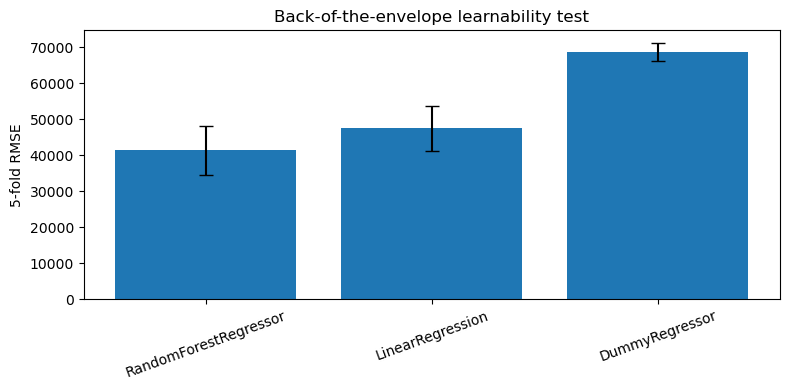

In [11]:
plotdf = resdf.sort_values("rmse_mean")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plotdf["model"], plotdf["rmse_mean"], yerr=plotdf["rmse_std"], capsize=5)
ax.set_ylabel("5-fold RMSE")
ax.set_title("Back-of-the-envelope learnability test")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Result Interpretation

Both machine learning models outperform the `DummyRegressor` baseline. The dummy model has an average RMSE of about 68.7K, while `LinearRegression` reduces RMSE to about 47.5K and `RandomForestRegressor` reduces it further to about 41.4K.

The best model, `RandomForestRegressor`, improves RMSE by roughly 27.3K over the dummy baseline. Its fold RMSE values range from about 34.6K to 50.1K, which shows that the model consistently beats the baseline but still has some variation across validation splits. Overall, the 2025 salary and production data contain clear learnable signal.


## 4. Domain & Technical Sanity Check

- **Institutional Constraints:** WNBA salaries are shaped by the CBA, max contract limits, rookie salary scales, free agency status, roster rules, and team salary-cap strategy. Because of these constraints, on-court production alone cannot fully explain salary.

- **Current Limitation:** We only use 2025 salary as the target now. A stronger prediction setup would train on prior-season to next-season pairs, such as 2024 stats to 2025 salary, before applying the model to 2025 stats for 2026 predictions.

## 5. Conclusion & Recommendations

The summary below reports the best model, the baseline RMSE, and the improvement over the dummy baseline.

In [12]:
best = resdf.sort_values("rmse_mean").iloc[0]
base = resdf.loc[resdf["model"].eq("DummyRegressor")].iloc[0]

print("Best model:", best["model"])
print("Best RMSE:", round(best["rmse_mean"], 2))
print("Dummy RMSE:", round(base["rmse_mean"], 2))
print("RMSE improvement:", round(best["gain"], 2))

Best model: RandomForestRegressor
Best RMSE: 41393.81
Dummy RMSE: 68737.03
RMSE improvement: 27343.22


The current 2025 dataset appears to be learnable for a basic salary-production modeling task. Both `LinearRegression` and `RandomForestRegressor` outperform the `DummyRegressor` baseline. The best model, `RandomForestRegressor`, achieves an average RMSE of about 41.4K compared with about 68.7K for `DummyRegressor`, improving RMSE by roughly 27.3K.

This suggests that player production and team-context features contain meaningful signal for explaining salary. However, the fold-level variation and single-season sample size mean that this result should be interpreted as an initial learnability check rather than a final valuation model.